In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib as mpl
import pandas as pd

In [2]:
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6
mpl.rcParams['figure.autolayout'] = True
mpl.rcParams['font.size'] = 15
mpl.rcParams['errorbar.capsize'] = 3
mpl.rcParams['lines.markeredgewidth'] = 1
mpl.rcParams['axes.axisbelow'] = True

In [3]:
def single_muon_direction(rng): # genera la dirección del muón aleatoriamente, sampleando de cos² para theta y uniforme para phi. El rng es para poder reproducir
                                # la misma lluvia en distintas iteraciones (para comparar con el detector fijo)
    while True:
        theta = rng.uniform(0,np.pi/2)
        if rng.uniform() < np.cos(theta)**2:
            break
    phi = rng.uniform(0,2*np.pi)
    return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),-np.cos(theta)])

def generate_muon(origin_size,z0,rate,rng): # genera muones con tiempo intermedio sampleado de una distribución exponencial, la dirección a partir de la función anterior y el punto
                                         # de origen se samplea uniformemente de un plano de origin_size x origin_size con el mismo centro en xy que los centelladores
    t = rng.exponential(scale=1/(rate*origin_size**2))
    origin = rng.uniform(-origin_size/2,origin_size/2,size=2)
    start = np.array([origin[0],origin[1],z0])
    flecha = single_muon_direction(rng)
    return t,start,flecha

def rotate_x(element,angle): # función para rotar los cuadrados
    Rx = np.array([
        [1, 0, 0],
        [0, np.cos(angle), -np.sin(angle)],
        [0, np.sin(angle),  np.cos(angle)]
    ])
    return element @ Rx.T

normal_angle = lambda ang : np.array([0,np.sin(ang),np.cos(ang)]) # como roto alrededor del eje x, defino la normal con componentes en z e y

def generar_lluvia(mode,origin_size,z0,rate,seed=0,t_f=0,n=0):
    rng = np.random.default_rng(seed)
    t = 0

    muon_times = []
    muon_paths = []

    if mode == 't':
        while t < t_f:
            new_t,start,flecha = generate_muon(origin_size,z0,rate,rng)
            t += new_t
            muon_times.append(t)
            muon_paths.append((start,flecha))

    elif mode == 'n':
        tot_muons = 0
        while tot_muons < n:
            new_t,start,flecha = generate_muon(origin_size,z0,rate,rng)
            t += new_t
            muon_times.append(t)
            muon_paths.append((start,flecha))
            tot_muons += 1

    else:
        print('Modo incorrecto')
        return None
    return muon_times,muon_paths

def ray_plane_intersection(start,flecha,center,normal): # calcula el punto por el que pasa la traza del muon al atravesar el plano que contiene al cuadrado
    denom = np.dot(normal,flecha)
    if np.abs(denom) < 1e-6:
        return None
    t = np.dot(normal,center-start) / denom
    intersection_point = start + t * flecha
    return intersection_point

def is_point_in_square(point,center,normal,side): # Crea una base ortonormal en el plano local del cuadrado, proyecta en los vectores de esa base el punto de intersección
                                                  # (trasladado al sistema local) y determina si ese punto está dentro del cuadrado
    u = np.cross(normal,np.array([0, 0, 1]))
    if np.linalg.norm(u) < 1e-6:
        u = np.cross(normal, np.array([0, 1, 0]))
    u = u / np.linalg.norm(u)
    v = np.cross(normal, u)

    local_point = point - center
    u_dist = np.dot(local_point, u)
    v_dist = np.dot(local_point, v)

    half_len = side / 2
    epsilon = 1e-10
    return (-half_len - epsilon <= u_dist <= half_len + epsilon) and (-half_len - epsilon <= v_dist <= half_len + epsilon)


def intersect_square(start,flecha,center,normal,side):
    point = ray_plane_intersection(start,flecha,center,normal)
    if point is None:
        return False
    return is_point_in_square(point,center,normal,side)

def intersect_detector(start,flecha,center_top,center_bottom,normal,side):
    return intersect_square(start,flecha,center_top,normal,side) or intersect_square(start,flecha,center_bottom,normal,side)

In [4]:
def sim_rotados_from_lluvia(lluvia,det_size,det_height,det_xy,det_delta,freq,seed=0):
    rng = np.random.default_rng(seed)

    ang0 = rng.uniform(0,2*np.pi)
    normal = normal_angle(ang0)
    center_top = np.array([*det_xy,det_delta/2])
    center_top_up = center_top + np.array([0,0,det_height])
    center_bottom = center_top - np.array([0,0,det_delta])
    center_bottom_down = center_bottom - np.array([0,0,det_height])

    muon_times = []
    muon_paths = []
    measured_angles = []
    empty_muon_paths = []
    empty_muon_times = []
    empty_angles = []

    times,paths = lluvia

    for i in range(len(times)):
        t = times[i]
        start,flecha = paths[i]

        ang = 2*np.pi*freq*t+ang0

        normal_new = normal_angle(ang)
        center_top_new = rotate_x(center_top,ang)
        center_top_up_new = rotate_x(center_top_up,ang)
        center_bottom_new = rotate_x(center_bottom,ang)
        center_bottom_down_new = rotate_x(center_bottom_down,ang)

        if intersect_detector(start,flecha,center_top_up_new,center_top_new,normal_new,det_size) and intersect_detector(start,flecha,center_bottom_new,center_bottom_down_new,normal_new,det_size):
            muon_times.append(t)
            muon_paths.append((start,flecha))
            measured_angles.append(ang)
        else:
            empty_muon_times.append(t)
            empty_muon_paths.append((start,flecha))
            empty_angles.append(ang)

    return muon_times,muon_paths,measured_angles,empty_muon_times,empty_muon_paths,empty_angles

def sim_fijos_from_lluvia(lluvia,det_size,det_height,det_xy,det_delta):
    normal = normal_angle(0)
    center_top = np.array([*det_xy,det_delta/2])
    center_top_up = center_top + np.array([0,0,det_height])
    center_bottom = center_top - np.array([0,0,det_delta])
    center_bottom_down = center_bottom - np.array([0,0,det_height])

    muon_paths = []
    empty_muon_paths = []

    times,paths = lluvia

    for i in range(len(times)):
        start,flecha = paths[i]

        if intersect_detector(start,flecha,center_top_up,center_top,normal,det_size) and intersect_detector(start,flecha,center_bottom,center_bottom_down,normal,det_size):
            muon_paths.append((start,flecha))
        else:
            empty_muon_paths.append((start,flecha))
    return muon_paths,empty_muon_paths

In [5]:
def sim_rotados_fast(lluvia,det_size,det_height,det_xy,det_delta,freq,seed=0):
    rng = np.random.default_rng(seed)

    ang0 = rng.uniform(0,2*np.pi)
    center_top = np.array([*det_xy,det_delta/2])
    center_top_up = center_top + np.array([0,0,det_height])
    center_bottom = center_top - np.array([0,0,det_delta])
    center_bottom_down = center_bottom - np.array([0,0,det_height])

    muon_times = []
    muon_paths = []
    measured_angles = []

    times,paths = lluvia

    for i in range(len(times)):
        t = times[i]
        start,flecha = paths[i]

        ang = 2*np.pi*freq*t+ang0

        normal_new = normal_angle(ang)
        center_top_new = rotate_x(center_top,ang)
        center_top_up_new = rotate_x(center_top_up,ang)

        if intersect_detector(start,flecha,center_top_up_new,center_top_new,normal_new,det_size):
            center_bottom_new = rotate_x(center_bottom,ang)
            center_bottom_down_new = rotate_x(center_bottom_down,ang)
            if intersect_detector(start,flecha,center_bottom_new,center_bottom_down_new,normal_new,det_size):
                muon_times.append(t)
                muon_paths.append((start,flecha))
                measured_angles.append(ang)

    return muon_times,muon_paths,measured_angles,times

In [6]:
def lluvia_to_csv(lluvia,name,path):
    times,paths = lluvia
    start_x = []
    start_y = []
    start_z = []
    flecha_x = []
    flecha_y = []
    flecha_z = []
    for i in range(len(times)):
        start,flecha = paths[i]
        start_x.append(start[0])
        start_y.append(start[1])
        start_z.append(start[2])
        flecha_x.append(flecha[0])
        flecha_y.append(flecha[1])
        flecha_z.append(flecha[2])
    df = pd.DataFrame([times,start_x,start_y,start_z,flecha_x,flecha_y,flecha_z])
    df.to_csv(f'{path}/{name}.csv')
    return df

def lluvia_from_csv(name,path):
    df = pd.read_csv(f'{path}/{name}.csv')
    times = np.array(df.iloc[:,0])
    start = np.array([df.iloc[:,1],df.iloc[:,2],df.iloc[:,3]])
    flecha = np.array([df.iloc[:,4],df.iloc[:,5],df.iloc[:,6]])
    paths = []
    for i in range(len(start)):
        paths.append((start[i],flecha[i]))

    return times,paths

In [7]:
lluvia = generar_lluvia('t',100,100,1/60,seed=0,t_f=10*24*360)

In [ ]:
lluvia_to_csv(lluvia,'10d_s0','/content/drive/MyDrive/Labos/Labo 6 7/simulacion inicial python/lluvias')

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


NameError: name 'lluvia_to_csv' is not defined

In [ ]:
muon_times,muon_paths,measured_angles,times = sim_rotados_fast(lluvia,det_size=4,det_height=0.5,det_xy=[0,0],det_delta=20,
                                                               freq=1,seed=0)

In [ ]:
fix_muon_paths,fix_empty_muon_paths = sim_fijos_from_lluvia(lluvia,det_size=4,det_height=0.5,
                                                            det_xy=[0,0],det_delta=20)

In [ ]:
24 hs 31 1440657
289 1440657

In [ ]:
print(len(muon_paths),len(muon_paths)+len(empty_muon_paths))
#print(len(fix_muon_paths),len(fix_muon_paths)+len(fix_empty_muon_paths))

NameError: name 'empty_muon_paths' is not defined

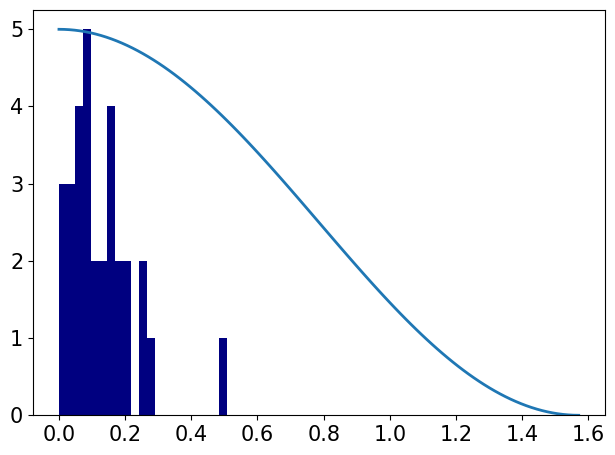

In [ ]:
modified_angles = []
for ang in measured_angles:
    ang %= np.pi
    if ang > np.pi/2:
        ang = np.pi - ang
    modified_angles.append(ang)

plt.hist(np.array(modified_angles),bins=21,color='navy')
#plt.axvline(np.pi,color='crimson',ls='--')
x = np.linspace(0,np.pi/2,100)
plt.plot(x,5*np.cos(x)**2)

In [ ]:
def draw_prism(ax, center, size, color='green', alpha=0.2):
    cx, cy, cz = center
    dx = dy = dz = size / 2
    v = np.array([
        [cx - dx, cy - dy, cz - dz],
        [cx + dx, cy - dy, cz - dz],
        [cx + dx, cy + dy, cz - dz],
        [cx - dx, cy + dy, cz - dz],
        [cx - dx, cy - dy, cz + dz],
        [cx + dx, cy - dy, cz + dz],
        [cx + dx, cy + dy, cz + dz],
        [cx - dx, cy + dy, cz + dz],
    ])
    faces = [
        [v[j] for j in [0, 1, 2, 3]],
        [v[j] for j in [4, 5, 6, 7]],
        [v[j] for j in [0, 1, 5, 4]],
        [v[j] for j in [2, 3, 7, 6]],
        [v[j] for j in [1, 2, 6, 5]],
        [v[j] for j in [3, 0, 4, 7]],
    ]
    ax.add_collection3d(Poly3DCollection(faces, facecolors=color, edgecolors='black', alpha=alpha))

def calculate_muon_end(start, direction, length=4000):
    return start + direction * length

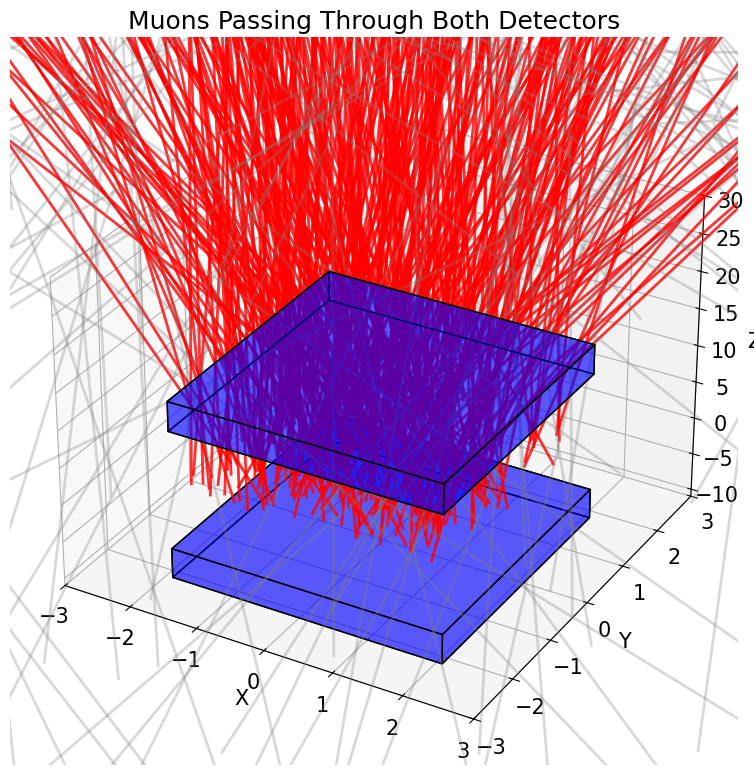

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

det_size = 4
det_delta = 20

draw_prism(ax, [0, 0, det_delta / 2], det_size, color='blue', alpha=0.4)
draw_prism(ax, [0, 0, -det_delta / 2], det_size, color='blue', alpha=0.4)

for (start, direction) in fix_muon_paths:
    end = calculate_muon_end(start, direction, length=100)
    ax.plot([start[0], end[0]], [start[1], end[1]], [start[2], end[2]], color='red', alpha=0.8)

for i, (start, direction) in enumerate(fix_empty_muon_paths):
    if i % 200 == 0:
        end = calculate_muon_end(start, direction, length=100)
        ax.plot([start[0], end[0]], [start[1], end[1]], [start[2], end[2]], color='gray', alpha=0.3)

ax.set_xlim([-3, 3])
ax.set_ylim([-3, 3])
ax.set_zlim([-det_delta / 2 - 1, det_delta / 2 + 20])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title("Muons Passing Through Both Detectors")
plt.tight_layout()
plt.show()